# Stock-level network feature analysis

This notebook audits and explores the eight stock-level ownership-network features produced by `scripts/17_build_stock_network_features.py`.

It examines:

1. stock-quarter coverage, keys, ranges, and missingness;
2. training-sample feature distributions;
3. redundancy within the network set and with institutional holder count;
4. training-only associations with forward maximum drawdown; and
5. temporal stability and dependence on the size of the manager graph.

Full-sample checks assess feature construction. Target relationships use only the training split, so validation and test outcomes do not influence the analysis. No saved data are modified.

## 1. Setup and inputs

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns


project_root = Path.cwd().resolve()

while not (project_root / 'config' / 'paths.yaml').is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError('Could not locate the project root.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


key = ['report_period', 'information_date', 'permno']
target = 'future_max_drawdown_63d'
network_features = [
    'owner_similarity_score',
    'value_weighted_owner_degree_centrality',
    'value_weighted_owner_neighbor_similarity',
    'owner_community_count',
    'owner_community_hhi',
    'largest_owner_community_share',
    'owner_similarity_score_change',
    'owner_community_hhi_change',
]
static_features = network_features[:6]
change_features = network_features[6:]
feature_labels = {
    'owner_similarity_score': 'Owner similarity',
    'value_weighted_owner_degree_centrality': 'Owner degree centrality',
    'value_weighted_owner_neighbor_similarity': 'Owner-neighbor similarity',
    'owner_community_count': 'Owner community count',
    'owner_community_hhi': 'Owner community HHI',
    'largest_owner_community_share': 'Largest community share',
    'owner_similarity_score_change': 'Owner similarity change',
    'owner_community_hhi_change': 'Owner community HHI change',
}

paths = get_paths_config()
network_directory = paths.interim / 'networks'
feature_path = network_directory / 'stock_network_features.parquet'
security_path = network_directory / 'ownership' / 'security_nodes.parquet'
manager_path = (
    network_directory / 'manager_communities' / 'manager_communities.parquet'
)
sample_path = paths.processed / 'modeling' / 'modeling_sample.parquet'

for description, path in {
    'stock network features': feature_path,
    'security nodes': security_path,
    'manager communities': manager_path,
    'modeling sample': sample_path,
}.items():
    if not path.is_file():
        raise FileNotFoundError(f'{description} not found: {path}')

features = pd.read_parquet(feature_path)
security_keys = pd.read_parquet(security_path, columns=key)
manager_keys = pd.read_parquet(
    manager_path,
    columns=['report_period', 'CIK'],
)
modeling_sample = pd.read_parquet(
    sample_path,
    columns=[*key, 'sample_split', target, 'institutional_holder_count'],
)
training = (
    modeling_sample.loc[modeling_sample['sample_split'].eq('train')]
    .merge(features, on=key, how='left', validate='one_to_one')
)

set_matplotlib_style()

print(f'Network-feature stock-quarters: {len(features):,}')
print(f'Network-feature quarters: {features["report_period"].nunique():,}')
print(f'Training stock-quarters: {len(training):,}')
print(f'Training quarters: {training["report_period"].nunique():,}')

Network-feature stock-quarters: 206,868
Network-feature quarters: 52
Training stock-quarters: 123,791
Training quarters: 34


## 2. Coverage, keys, and missingness

Every ownership-network security node should have one feature row. Static features must always be present; change features should be present only when the security also appears in the immediately preceding quarter.

In [2]:
duplicate_rows = int(features.duplicated(key).sum())
coverage = security_keys.merge(
    features[key],
    on=key,
    how='outer',
    indicator=True,
    validate='one_to_one',
)
coverage_summary = (
    coverage['_merge'].value_counts()
    .rename_axis('coverage_status')
    .reset_index(name='rows')
)

ordered = features.sort_values(['permno', 'report_period']).copy()
quarter_number = (
    ordered['report_period'].dt.year * 4
    + ordered['report_period'].dt.quarter
)
previous_quarter = quarter_number.groupby(ordered['permno']).shift()
expected_change = quarter_number.sub(previous_quarter).eq(1)
available_change = ordered[change_features].notna().all(axis=1)
partial_change_rows = int(ordered[change_features].isna().any(axis=1).ne(
    ordered[change_features].isna().all(axis=1)
).sum())
inconsistent_change_rows = int(expected_change.ne(available_change).sum())
bounded_features = [
    'owner_similarity_score',
    'value_weighted_owner_degree_centrality',
    'value_weighted_owner_neighbor_similarity',
    'owner_community_hhi',
    'largest_owner_community_share',
]
invalid_static_rows = int((
    ~features[bounded_features].apply(
        lambda values: values.between(0, 1)
    ).all(axis=1)
    | features['owner_community_count'].lt(1)
).sum())
invalid_change_values = int(
    features[change_features].apply(
        lambda values: (~values.dropna().between(-1, 1)).sum()
    ).sum()
)

missingness = pd.DataFrame(
    {
        'missing_rows': features[network_features].isna().sum(),
        'missing_share': features[network_features].isna().mean(),
    }
).rename_axis('feature').reset_index()

if duplicate_rows:
    raise RuntimeError('Network features contain duplicate stock-quarters.')
if not coverage['_merge'].eq('both').all():
    raise RuntimeError('Network-feature coverage differs from security nodes.')
if features[static_features].isna().any().any():
    raise RuntimeError('Static network features contain missing values.')
if partial_change_rows or inconsistent_change_rows:
    raise RuntimeError('Change-feature availability is inconsistent.')
if invalid_static_rows or invalid_change_values:
    raise RuntimeError('Network features contain out-of-range values.')
if training[static_features].isna().any().any():
    raise RuntimeError('Training observations did not merge completely.')

display(coverage_summary.style.format({'rows': '{:,}'}))
display(
    missingness.style.format(
        {'missing_rows': '{:,}', 'missing_share': '{:.2%}'}
    )
)
print(f'Duplicate stock-quarters: {duplicate_rows:,}')
print(f'Partial change-feature rows: {partial_change_rows:,}')
print(f'Inconsistent change-feature rows: {inconsistent_change_rows:,}')
print(f'Rows with invalid static values: {invalid_static_rows:,}')
print(f'Invalid change values: {invalid_change_values:,}')

,coverage_status,rows
0,both,"206,868"
1,left_only,0
2,right_only,0


,feature,missing_rows,missing_share
0,owner_similarity_score,0,0.00%
1,value_weighted_owner_degree_centrality,0,0.00%
2,value_weighted_owner_neighbor_similarity,0,0.00%
3,owner_community_count,0,0.00%
4,owner_community_hhi,0,0.00%
5,largest_owner_community_share,0,0.00%
6,owner_similarity_score_change,"7,373",3.56%
7,owner_community_hhi_change,"7,373",3.56%


Duplicate stock-quarters: 0
Partial change-feature rows: 0
Inconsistent change-feature rows: 0
Rows with invalid static values: 0
Invalid change values: 0


## 3. Training-sample distributions

Summary statistics use all training observations. Histograms are capped at each feature's 1st and 99th percentiles for readability only; the data and modeling inputs are not altered.

,feature,observations,missing_share,p01,median,p99,skewness
0,owner_similarity_score,"123,791",0.00%,0.0000,0.0924,0.3081,2.94
1,value_weighted_owner_degree_centrality,"123,791",0.00%,0.0082,0.0344,0.0879,1.20
2,value_weighted_owner_neighbor_similarity,"123,791",0.00%,0.1322,0.4365,0.7074,-0.20
3,owner_community_count,"123,791",0.00%,2.0000,8.0000,13.0000,-0.07
4,owner_community_hhi,"123,791",0.00%,0.2179,0.4017,0.9880,1.25
5,largest_owner_community_share,"123,791",0.00%,0.2939,0.5443,0.9940,0.64
6,owner_similarity_score_change,"120,052",3.02%,-0.1059,-0.0006,0.1004,-0.20
7,owner_community_hhi_change,"120,052",3.02%,-0.5477,-0.0017,0.5151,-0.12


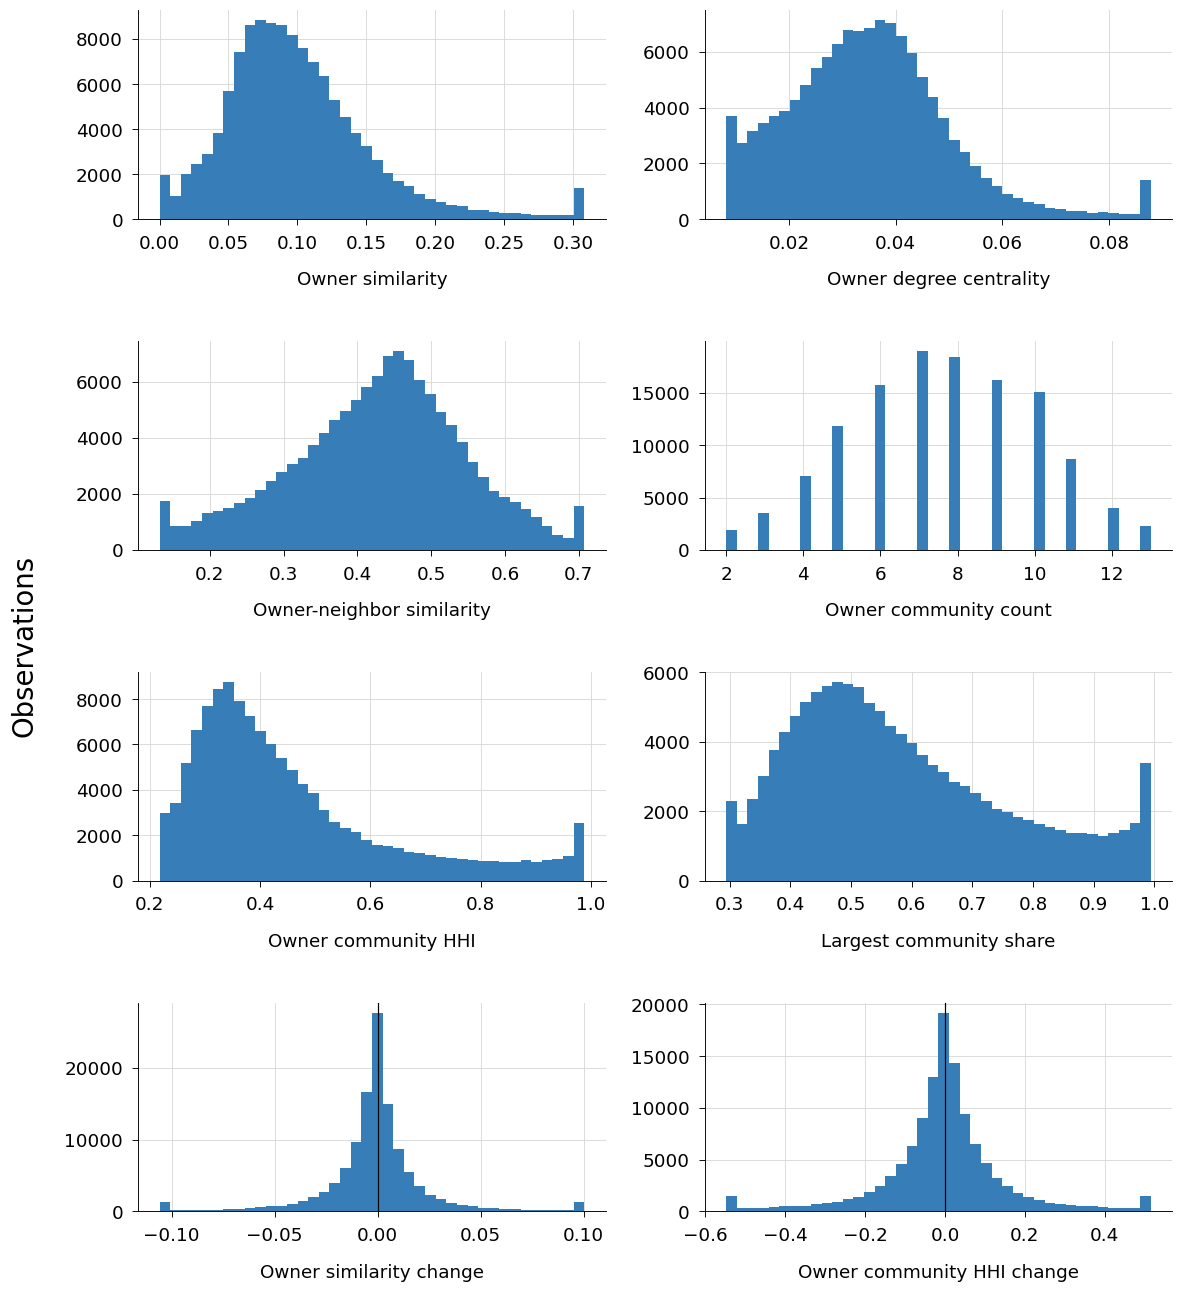

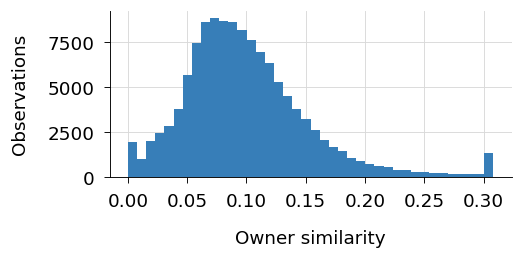

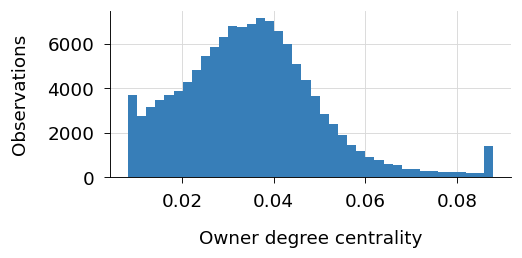

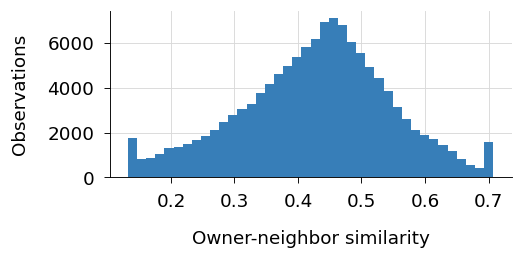

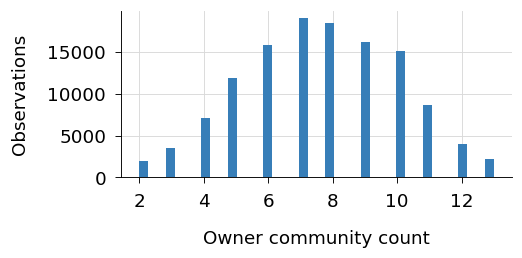

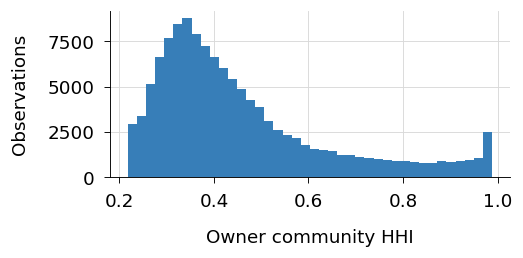

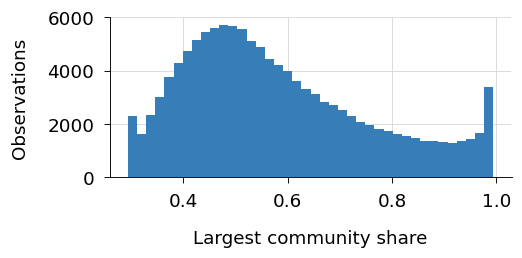

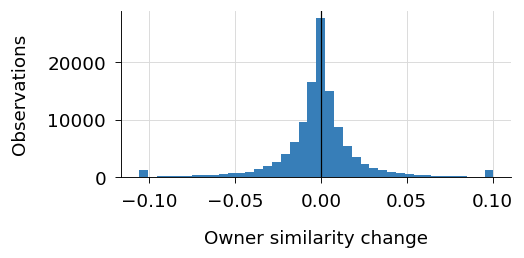

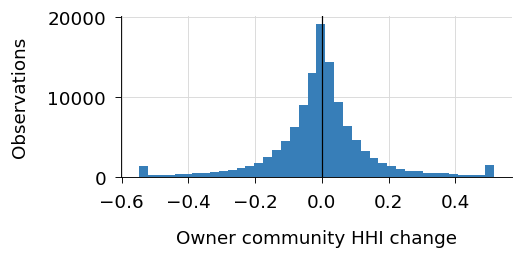

In [3]:
feature_summary = pd.DataFrame(
    {
        'feature': network_features,
        'observations': training[network_features].count().to_numpy(),
        'missing_share': training[network_features].isna().mean().to_numpy(),
        'p01': training[network_features].quantile(0.01).to_numpy(),
        'median': training[network_features].median().to_numpy(),
        'p99': training[network_features].quantile(0.99).to_numpy(),
        'skewness': training[network_features].skew().to_numpy(),
    }
)
display(
    feature_summary.style.format(
        {
            'observations': '{:,}',
            'missing_share': '{:.2%}',
            'p01': '{:.4f}',
            'median': '{:.4f}',
            'p99': '{:.4f}',
            'skewness': '{:.2f}',
        }
    )
)

figure, axes = plt.subplots(4, 2, figsize=(11, 12))
for axis, feature in zip(axes.flat, network_features):
    values = training[feature].dropna()
    display_values = values.clip(
        lower=values.quantile(0.01),
        upper=values.quantile(0.99),
    )
    axis.hist(display_values, bins=40, color=COLOR_PALETTE[0])
    if feature in change_features:
        axis.axvline(0, color='black', linewidth=0.8)
    axis.set_xlabel(feature_labels[feature])

figure.supylabel('Observations')

apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "02_04_feature_distributions.pdf")
plt.show()

for index, feature in enumerate(network_features, start=1):
    values = training[feature].dropna()
    display_values = values.clip(
        lower=values.quantile(0.01),
        upper=values.quantile(0.99),
    )

    figure, axis = plt.subplots(figsize=(5, 2.6))
    axis.hist(display_values, bins=40, color=COLOR_PALETTE[0])
    if feature in change_features:
        axis.axvline(0, color='black', linewidth=0.8)
    axis.set_xlabel(feature_labels[feature])
    axis.set_ylabel('Observations')
    apply_matplotlib_layout(figure)
    figure.savefig(
        paths.figures
        / f'02_04_feature_distribution_{index:02d}_{feature}.pdf'
    )
    plt.show()

## 4. Training-period redundancy

Network features are converted to within-quarter percentile ranks, matching the treatment later applied by Script 18. Spearman correlations then document overlap within the frozen network set.

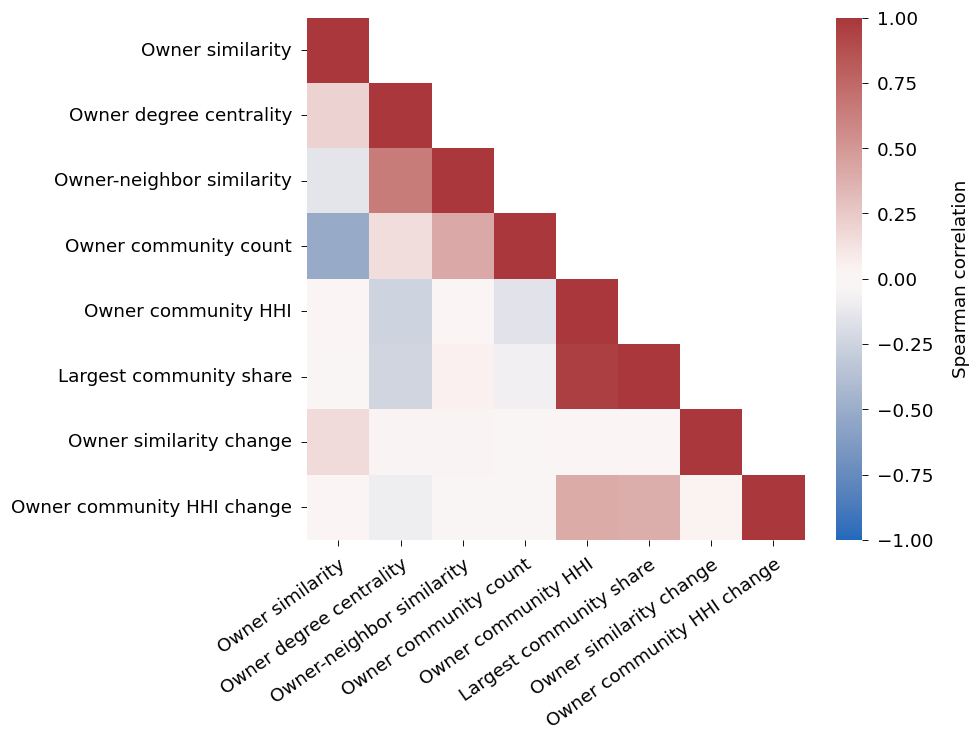

,feature_1,feature_2,spearman
0,Owner community HHI,Largest community share,0.958
1,Owner community count,Holder count,0.890
2,Owner degree centrality,Owner-neighbor similarity,0.644


In [4]:
rank_columns = [*network_features, 'institutional_holder_count']
grouped = training.groupby('report_period')[rank_columns]
ranks = grouped.rank(method='average')
counts = grouped.transform('count')
percentile_ranks = (ranks - 1) / (counts - 1)
percentile_ranks = percentile_ranks.where(counts.ne(1), 0.5)
network_correlations = percentile_ranks[network_features].corr(
    method='spearman'
)
network_correlations = network_correlations.rename(
    index=feature_labels,
    columns=feature_labels,
)
mask = np.triu(np.ones_like(network_correlations, dtype=bool), k=1)

figure, axis = plt.subplots(figsize=(9, 7))
sns.heatmap(
    network_correlations,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Spearman correlation'},
    ax=axis,
)
axis.set_xticklabels(
    axis.get_xticklabels(),
    rotation=35,
    ha='right',
    rotation_mode='anchor',
)
axis.set_yticklabels(axis.get_yticklabels(), rotation=0)
axis.grid(False)
#axis.set_title('Training-sample network-feature correlations')
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "02_04_feature_correlation_heatmap.pdf")
plt.show()

diagnostic_pairs = [
    ('owner_community_hhi', 'largest_owner_community_share'),
    ('owner_community_count', 'institutional_holder_count'),
    (
        'value_weighted_owner_degree_centrality',
        'value_weighted_owner_neighbor_similarity',
    ),
]
diagnostic_correlations = pd.DataFrame(
    [
        {
            'feature_1': feature_labels.get(feature_1, 'Holder count'),
            'feature_2': feature_labels.get(feature_2, 'Holder count'),
            'spearman': percentile_ranks[feature_1].corr(
                percentile_ranks[feature_2], method='spearman'
            ),
        }
        for feature_1, feature_2 in diagnostic_pairs
    ]
)
display(diagnostic_correlations.style.format({'spearman': '{:.3f}'}))

## 5. Training-only target associations

For every training quarter, a Spearman correlation is calculated between each raw network feature and forward maximum drawdown. The graph reports the mean quarterly correlation, matching the thesis's emphasis on within-quarter prediction.

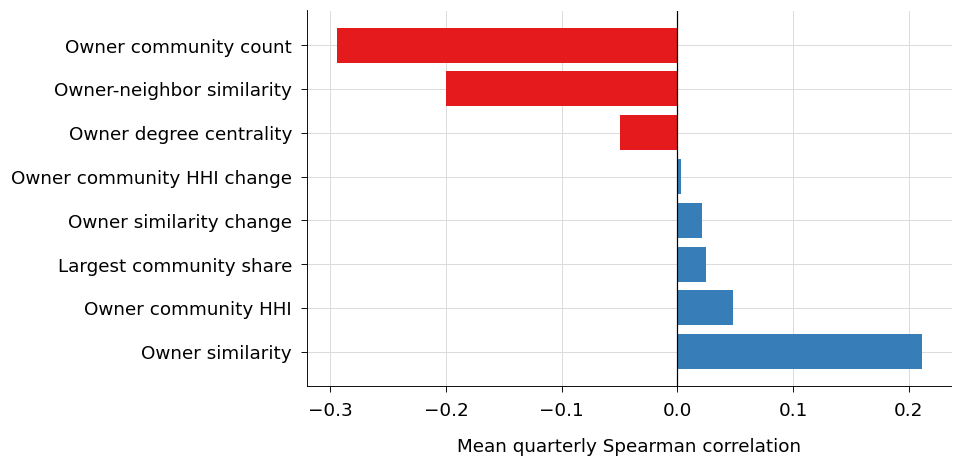

,spearman
Owner community count,-0.295
Owner-neighbor similarity,-0.200
Owner degree centrality,-0.049
Owner community HHI change,0.003
Owner similarity change,0.021
Largest community share,0.024
Owner community HHI,0.048
Owner similarity,0.211


In [5]:
quarterly_target_correlations = pd.DataFrame(
    {
        feature: training.groupby('report_period').apply(
            lambda quarter: quarter[feature].corr(
                quarter[target], method='spearman'
            ),
            include_groups=False,
        )
        for feature in network_features
    }
)
target_associations = (
    quarterly_target_correlations.mean()
    .rename(index=feature_labels)
    .sort_values()
)
bar_colors = [
    COLOR_PALETTE[1] if value < 0 else COLOR_PALETTE[0]
    for value in target_associations
]

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.barh(target_associations.index, target_associations, color=bar_colors)
axis.axvline(0, color='black', linewidth=0.8)
axis.invert_yaxis()
#axis.set_title('Mean quarterly association with forward maximum drawdown')
axis.set_xlabel('Mean quarterly Spearman correlation')
axis.set_ylabel('')
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "02_04_target_association_barh.pdf")
plt.show()

display(target_associations.rename('spearman').to_frame().style.format('{:.3f}'))

## 6. Binned target relationships

Within-quarter percentile ranks are divided into deciles. Mean target values across deciles show whether each network feature has a monotonic or nonlinear relationship with subsequent drawdown.

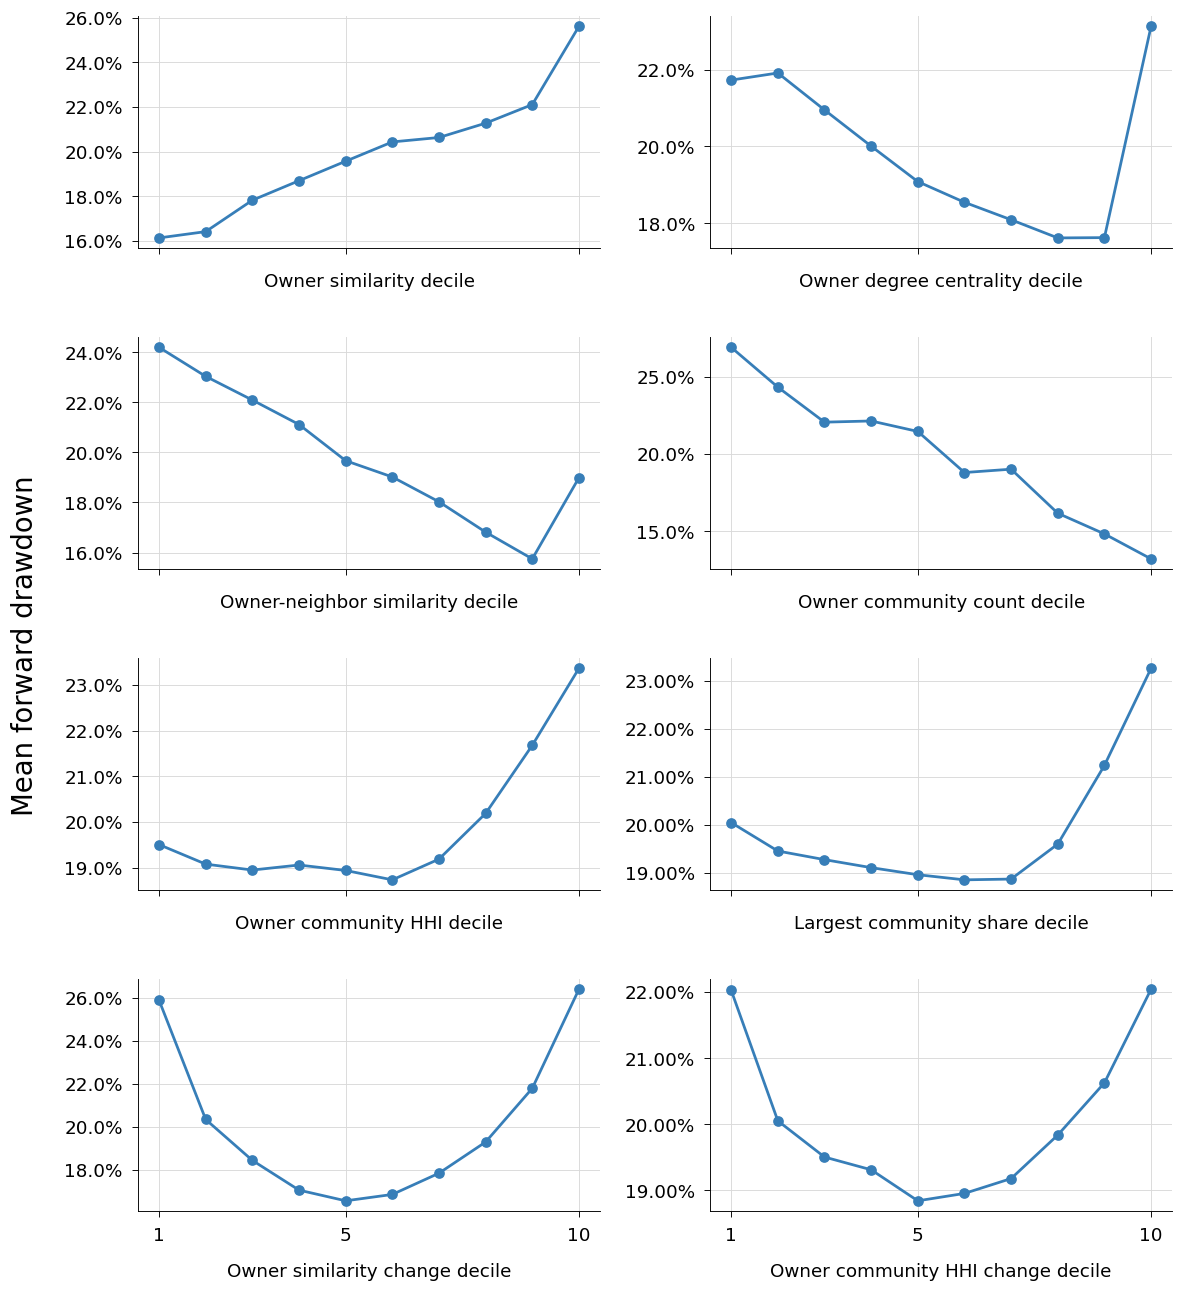

,feature,decile_1_drawdown,decile_10_drawdown,decile_10_minus_1
0,Owner similarity,16.13%,25.61%,+9.47%
1,Owner degree centrality,21.73%,23.13%,+1.40%
2,Owner-neighbor similarity,24.19%,18.99%,-5.20%
3,Owner community count,26.89%,13.22%,-13.67%
4,Owner community HHI,19.51%,23.36%,+3.86%
5,Largest community share,20.05%,23.26%,+3.22%
6,Owner similarity change,25.88%,26.39%,+0.51%
7,Owner community HHI change,22.03%,22.04%,+0.02%


In [6]:
relationship_rows = []
figure, axes = plt.subplots(4, 2, figsize=(11, 12), sharex=True)

for axis, feature in zip(axes.flat, network_features):
    feature_decile = (
        np.floor(percentile_ranks[feature] * 10) + 1
    ).clip(upper=10)
    relationship = (
        training.assign(feature_decile=feature_decile)
        .dropna(subset=['feature_decile'])
        .groupby('feature_decile', as_index=False)[target]
        .mean()
    )
    relationship_rows.append(
        {
            'feature': feature_labels[feature],
            'decile_1_drawdown': relationship.loc[
                relationship['feature_decile'].eq(1), target
            ].iloc[0],
            'decile_10_drawdown': relationship.loc[
                relationship['feature_decile'].eq(10), target
            ].iloc[0],
        }
    )

    axis.plot(
        relationship['feature_decile'],
        relationship[target],
        marker='o',
        color=COLOR_PALETTE[0],
    )
    axis.set_xlabel(f'{feature_labels[feature]} decile')
    axis.set_xticks([1, 5, 10])
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))

figure.supylabel('Mean forward drawdown')

apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "02_04_binned_target_relationships.pdf")
plt.show()

relationship_summary = pd.DataFrame(relationship_rows)
relationship_summary['decile_10_minus_1'] = (
    relationship_summary['decile_10_drawdown']
    - relationship_summary['decile_1_drawdown']
)
display(
    relationship_summary.style.format(
        {
            'decile_1_drawdown': '{:.2%}',
            'decile_10_drawdown': '{:.2%}',
            'decile_10_minus_1': '{:+.2%}',
        }
    )
)

## 7. Temporal stability and graph size

Quarterly medians reveal shifts in the raw network structure. Their correlations with the number of reporting managers indicate whether feature levels partly track changes in graph size; Script 18 later limits this issue by ranking features within each quarter.

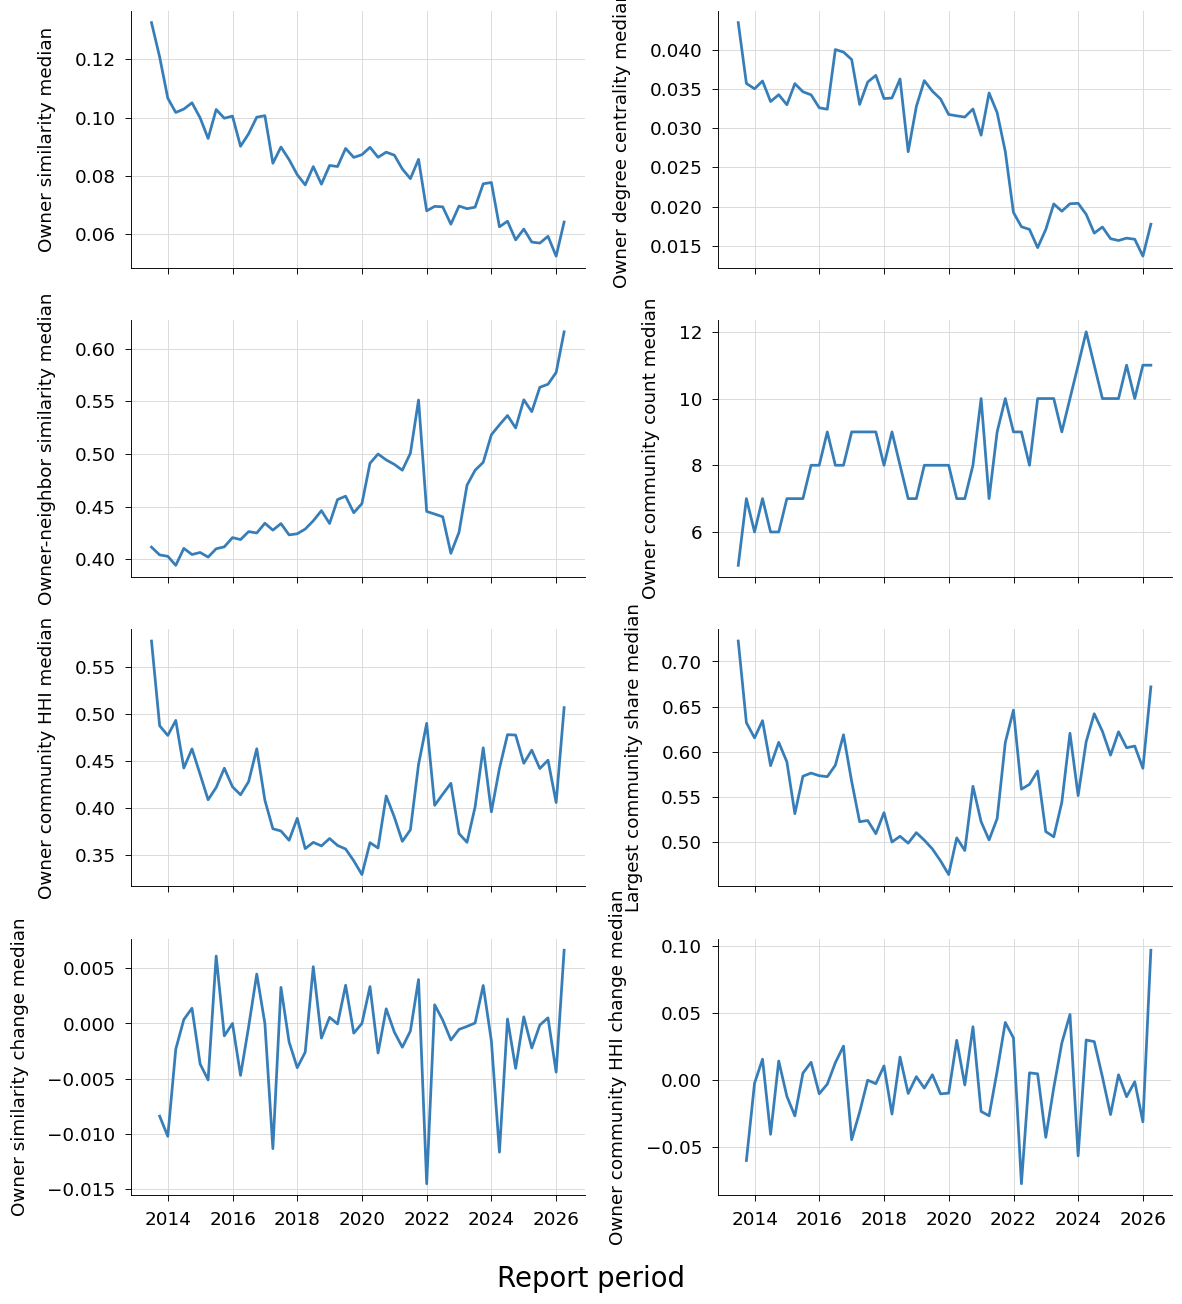

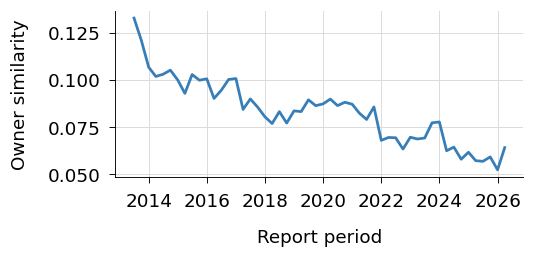

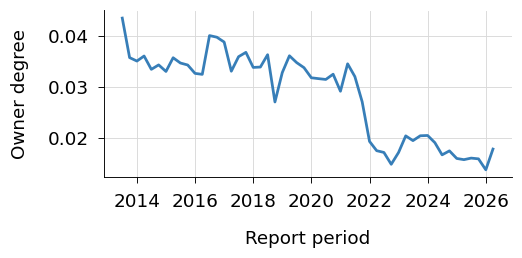

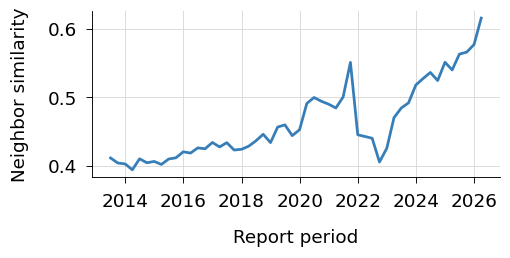

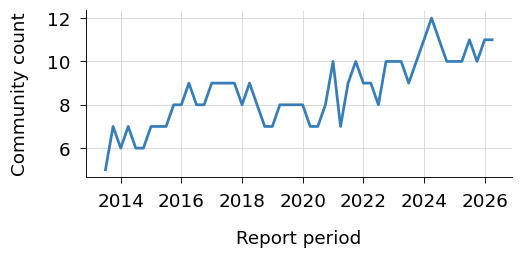

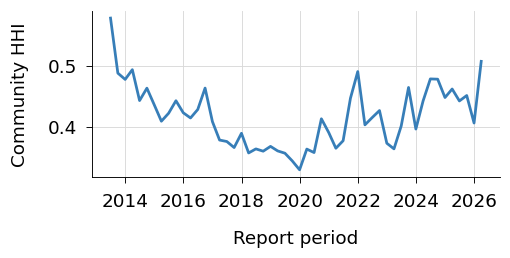

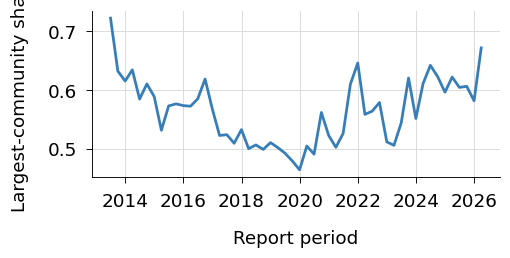

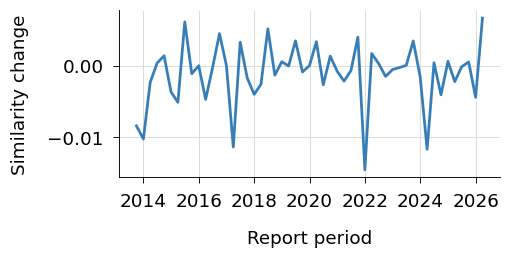

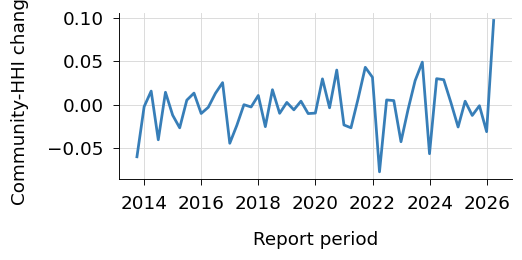

,manager_count_spearman
Owner similarity,-0.922
Owner degree centrality,-0.855
Owner community HHI,-0.027
Largest community share,0.041
Owner similarity change,0.101
Owner community HHI change,0.112
Owner community count,0.803
Owner-neighbor similarity,0.865


In [7]:
quarterly_medians = (
    features.groupby('report_period')[network_features]
    .median()
    .sort_index()
)
manager_count = manager_keys.groupby('report_period')['CIK'].nunique()
graph_size_correlations = (
    quarterly_medians.apply(lambda values: values.corr(manager_count, method='spearman'))
    .rename(index=feature_labels)
    .rename('manager_count_spearman')
    .sort_values()
)

figure, axes = plt.subplots(4, 2, figsize=(11, 12), sharex=True)
for axis, feature in zip(axes.flat, network_features):
    axis.plot(
        quarterly_medians.index,
        quarterly_medians[feature],
        color=COLOR_PALETTE[0],
    )
    axis.set_ylabel(f'{feature_labels[feature]} median')

figure.supxlabel('Report period')

apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "02_04_temporal_stability.pdf")
plt.show()

temporal_axis_labels = {
    'owner_similarity_score': 'Owner similarity',
    'value_weighted_owner_degree_centrality': 'Owner degree',
    'value_weighted_owner_neighbor_similarity': 'Neighbor similarity',
    'owner_community_count': 'Community count',
    'owner_community_hhi': 'Community HHI',
    'largest_owner_community_share': 'Largest-community share',
    'owner_similarity_score_change': 'Similarity change',
    'owner_community_hhi_change': 'Community-HHI change',
}

for index, feature in enumerate(network_features, start=1):
    figure, axis = plt.subplots(figsize=(5, 2.6))
    axis.plot(
        quarterly_medians.index,
        quarterly_medians[feature],
        color=COLOR_PALETTE[0],
    )
    axis.set_ylabel(temporal_axis_labels[feature])
    axis.set_xlabel('Report period')
    apply_matplotlib_layout(figure)
    figure.savefig(
        paths.figures
        / f'02_04_temporal_stability_{index:02d}_{feature}.pdf'
    )
    plt.show()

display(
    graph_size_correlations.to_frame().style.format('{:.3f}')
)

## 8. Interpretation

- **Construction and coverage are correct.** The table contains 206,868 unique stock-quarter observations across 52 quarters and matches the security-node universe exactly. All static features are present and within their valid ranges. The two change features are simultaneously available exactly when a consecutive-quarter predecessor exists.
- **Missingness is limited to changes.** The static features have no missing values. Both change variables are missing for 3.56% of the complete feature table and 3.02% of the training sample, reflecting entry or gaps in a security's quarterly history rather than failed computation.
- **Some frozen features are strongly related but not identical.** Within the training sample, owner-community HHI and largest-community share have a Spearman correlation of 0.958. Owner-community count correlates 0.890 with institutional holder count, confirming that it partly captures breadth of ownership. Owner degree centrality and owner-neighbor similarity are less redundant, with correlation of 0.644.
- **Owner similarity and community breadth contain the clearest univariate signal.** Mean quarterly target correlation is 0.211 for owner similarity, -0.295 for owner-community count, and -0.200 for owner-neighbor similarity. The remaining level features are weaker, while both change features have correlations close to zero.
- **The decile patterns confirm the main associations.** Mean future drawdown rises by 9.47 percentage points from the lowest to highest owner-similarity decile, falls by 13.67 points across owner-community-count deciles, and falls by 5.20 points across owner-neighbor-similarity deciles. The two change features have D10–D1 spreads of only 0.51 and 0.02 percentage points.
- **Raw feature levels depend materially on graph size.** Quarterly manager count correlates -0.922 with median owner similarity, -0.855 with owner degree centrality, 0.803 with owner-community count, and 0.865 with owner-neighbor similarity. This is not a construction error, but it supports transforming every network feature into a within-quarter percentile rank before modeling.

The eight-feature set can proceed to the modeling-sample stage. Strongly correlated features should be interpreted as related network constructs, and the weak standalone performance of change features should be tested through out-of-sample model comparison rather than removed using training outcomes alone.